1. Build the Network
2. Forward Propagation
3. Caculate the Loss
4. Back Propagation
5. Gradient Decent Optimization
6. Repeat

## **2. Forward Propagation**

- Data flows throught the network layer by layer - 
- From the input layer to the output layer
- Forward pass --> Feed Forward

Steps:
1. Input enters the first layer
2. Weighted sum is calculated
3. Activation is applied
4. Ouput passed to the next layer and same steps applied
5. Process repeated upto the ouput layer
6. Final Prediction is made
- Final prediction (`y_pred`) will contain all the outputs for all the respective inputs(that can have multiple features as well)

## **3. Caculate the Loss**

- The network compares its predicted output `y_pred` to the actual labels `y_test`
- Using a Loss Function, total error is calculated - how accurate the prediction is
- 
- Loss Functions:

function | action | use
----|---|-----
Mean Squared Error (MSE) | Calculates the average of the squared differences between y' and y (Residuals) | Used for Regression Tasks
Binary Cross Entropy (BCE) | Measures teh distance between two probability distributions (`P(y')` and `P(y)`) | Used for Binary Classification (can pair it up with `Sigmoid` as activation function)
Categorical Cross Entropy (CCE) | Similar to BCE, but used on multiple classes | Used for Multi-Class Classification (can pair it up with `Softmax` as activation function)

- **Binary Cross Entropy (BCE)** - Log Loss- 

$$L=−(ylog(y^​)+(1−y)log(1−y^​))$$


- Entropy: A simple definition of entropy is that it is a calculation of the degree of randomness or disorder within a system
- Cross Entropy: measures the differences between two probability distributions


[Learn About Loss Functions](https://www.geeksforgeeks.org/deep-learning/loss-functions-in-deep-learning/)

> **Loss Functions in Deep Learning**
- **`sparse_categorical_crossentropy`**: For multi-class classification with integer labels; calculates the cross-entropy between true labels and predicted probabilities.  
- **`categorical_crossentropy`**: For multi-class classification with one-hot encoded labels; computes cross-entropy for each class.  
- **`binary_crossentropy`**: For binary classification; measures the log loss for two classes.  
- **`mean_squared_error` (MSE)**: For regression; computes the squared difference between predicted and true values.  
- **`mean_absolute_error` (MAE)**: For regression; computes the absolute difference between predictions and targets.  
- **`huber_loss`**: For regression; combines MSE and MAE, robust to outliers.  
- **`mean_absolute_percentage_error` (MAPE)**: For regression; calculates the percentage difference between predictions and actual values.  
- **`hinge`**: For binary classification with labels -1 and 1; used in SVMs, penalizes misclassified samples.  
- **`squared_hinge`**: Variation of hinge loss; penalizes the square of hinge loss for misclassifications.  
- **`poisson`**: For count-based data; computes the Poisson deviance between true and predicted values.  
- **`cosine_similarity`**: Measures the cosine similarity between true and predicted vectors; useful for directional data.  
- **`log_cosh`**: For regression; similar to MSE but less sensitive to large errors.  
- **`kullback_leibler_divergence` (KLD)**: Measures divergence between two probability distributions, true and predicted.  
- **`custom_loss`**: User-defined function tailored to specific requirements in a model.  

## **4. Back Propagation**

- Now the network knows how wrong it it
- Back propagation works backwards from Ouput ---> input
- Calculate the gradient or loss
- Update weights using Gradient Decent
- Weight update: 
$$W=W−η. ∂L/∂W $$
- 
- **Updated weight = weight - learning rate * gradient**
- 
- Chain rules of calculus are used, to compute gradient (partial derivatives) of the loss function with respect to every single weight and bias  $\frac{\partial L}{\partial w}$
- To calculate the Gradient, we use OPTIMIZERS

## **5. Optimization - Weight Update - Gradient Decent**

- Optimization in deep learning is a crucial process that involves **adjusting the parameters** of a neural network to minimize the loss function and improve the model's performance

- Optimization algorithms, known as optimizers, play a significant role in this process by dynamically fine-tuning the model's parameters during training

- 

[Optimzers - medium article](https://medium.com/@sushmita2310/types-of-optimizers-in-deep-learning-a-comprehensive-guide-af258d6acf66)

**Gradient Descent**

Gradient Descent is a fundamental optimization algorithm that iteratively adjusts the model's parameters to minimize the loss function.

**Stochastic Gradient Descent (SGD)**

SGD is a variation of Gradient Descent that processes one training example at a time, making it more efficient for large datasets. It introduces randomness by selecting a random subset of the data for each iteration, which helps in **escaping local minima**.

**Adam**

Adam (Adaptive Moment Estimation) combines the strengths of both Momentum and RMSProp. It adapts the learning rate for each parameter based on the first and second moments of the gradient. Adam is widely used in deep learning due to its fast convergence and low memory requirements.


**AdaGrad**

- AdaGrad adapts the **learning rate for each parameter** based on the **historical gradient information**. 
- It is particularly useful for sparse datasets, as it allows each parameter to have its own learning rate.




Optimizer | action | use
-----|----|----
Adam (adaptive movement estimation)| adjusts the learning rate for each weight | Generalizes better - almost 95% of NN projects use it. Fast, efficient. Computer vision, GANs, reinforcement learning, RNNs, LSTMs
AdamW | | NLP, transformers
SGD (stochastic gradient decent)| take steps based on the current gradient | used in advanced research, finds better solutions than Adam sometimes. CV
AdaGrad | adapts the learning rate for each parameter  | Good for sparse features
RMSprop | | RNNs


## **6. Repeat (Epochs)**

- The network does not learn everything at once
- Repeats these steps a couple of time over ---> each repetition is called an Epoch
- Epoch - One complete pass of the **entire dataset** through the model
- Instead of updating weights after looking at every input, we do this in ---> batches
    - Imagine we have 60000 images
    - Each image has to pass through the network
    - Would we update the network 60K times?
    - So, we generally train in Batches
    - 
- Batch Size - how many data points the network processes before updating weights 
    - Rule of thumb: 
    - 32 is default
    - if computer runs out of memory, lower it to 16
    - if you have a powerful GPU, try 64 or 128 as well

- SOmetimes we can use this technique called Early Stopping
    - if the model is not improving performance, you can stop the training process early
    - this will prevent it form memorizing the data (OVERFITTING)

---

## An Example -  Mnist dataset
- Loop over different optimzers to check which one does better
- 

In [7]:
import warnings
warnings.filterwarnings('ignore')

In [1]:
import keras
from keras.datasets import mnist
from keras.models import Sequential
from keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPooling2D
from keras import backend as K

In [ ]:
# Load the dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()

x_train = x_train.reshape(x_train.shape[0], 28, 28, 1)
x_test = x_test.reshape(x_test.shape[0], 28, 28, 1)
input_shape = (28, 28, 1)

y_train = keras.utils.to_categorical(y_train)
y_test = keras.utils.to_categorical(y_test)
x_train = x_train.astype('float32') / 255
x_test = x_test.astype('float32') / 255

In [ ]:
# Custom build the model
# this is a CNN
def build_model(optimizer):
    model = Sequential()
    model.add(Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=input_shape))
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Dropout(0.25))
    model.add(Flatten())
    model.add(Dense(256, activation='relu'))
    model.add(Dropout(0.5))
    model.add(Dense(10, activation='softmax'))
    
    model.compile(loss=keras.losses.categorical_crossentropy, optimizer=optimizer, metrics=['accuracy'])
    return model

In [9]:
# Train the model with different optimizers
# want to check how well each of these is doing
optimizers = ['Adadelta', 'Adagrad', 'Adam', 'RMSprop', 'SGD']

for opt in optimizers:
    model = build_model(opt)
    model.fit(x_train, y_train, batch_size=64, epochs=1, verbose=0, validation_data=(x_test, y_test))

#### Looping over the optimizers

In [ ]:
# Train the model with different optimizers
# want to check how well each of these is doing
import time

optimizers = ['Adadelta', 'Adagrad', 'Adam', 'RMSprop', 'SGD']

results = {}

for opt in optimizers:
    model = build_model(opt)

    # start flag
    start_time = time.time()
    history = model.fit(x_train, y_train, batch_size = 64, epochs=10, verbose=0, validation_data=(x_test, y_test))
    # stop flag
    end_time = time.time()

    # save the history in a dictionary
    results[opt] = history.history
    results[opt]['Training Time'] = end_time - start_time

In [22]:
# results

- we can compare validation accuracies over the epochs, to check:
    - which optimizer got the best accuracy
    - which optimizer converged the fastest

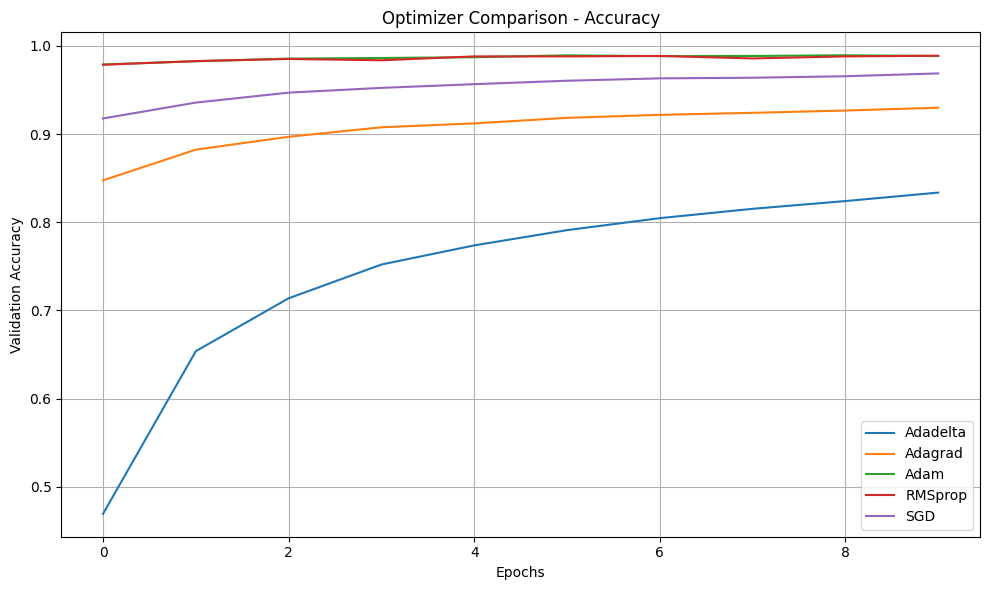

In [26]:
import matplotlib.pyplot as plt

# Plot Accuracy
plt.figure(figsize=(10, 6))

for key, value in results.items():
    plt.plot( value['val_accuracy'] , label = key)


plt.xlabel('Epochs')
plt.ylabel('Validation Accuracy')
plt.title("Optimizer Comparison - Accuracy")
plt.grid()
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
final_adam_acc = results['Adam']['val_accuracy'][-1]
print(f"Adam finished with {final_adam_acc*100:.2f}% accuracy")

final_rmsprop_acc = results['RMSprop']['val_accuracy'][-1]
print(f"RMSprop finished with {final_rmsprop_acc*100:.2f}% accuracy")

Adam finished with 98.85% accuracy
RMSprop finished with 98.89% accuracy
